# Ride-Sharing Trip Analysis

## Objective

Analyze ride-sharing trip data stored in protobuf format
to identify operational patterns, cancellations,
revenue drivers, and peak-demand behavior.

The project includes:
- protobuf data parsing
- exploratory data analysis (EDA)
- feature engineering
- business KPI analysis
- visualization and insights


## 1. Imports

In [2]:
import trip_pb2
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## 2. LOAD PROTOBUF DATA

# Data Loading

The raw dataset is stored in protobuf binary format.
The protobuf schema is used to deserialize records
into structured Python objects.

In [3]:
trip_batch = trip_pb2.TripBatch()

with open("trips.pb", "rb") as f:
    trip_batch.ParseFromString(f.read())

records = []

for trip in trip_batch.trips:

    records.append({
        "trip_id": trip.trip_id,
        "driver_id": trip.driver_id,
        "rider_id": trip.rider_id,
        "city": trip.city,

        "vehicle_type":
        trip_pb2.VehicleType.Name(
            trip.vehicle_type
        ),

        "fare": trip.fare,
        "distance_km": trip.distance_km,

        "timestamp":
        pd.to_datetime(
            trip.timestamp,
            unit="s"
        ),

        "status":
        trip_pb2.TripStatus.Name(
            trip.status
        )
    })

df = pd.DataFrame(records)

df.head()

,trip_id,driver_id,rider_id,city,vehicle_type,fare,distance_km,timestamp,status
0,20001,2778,11602,Mumbai,AUTO,61.740002,3.59,2025-04-26 08:37:17,REQUESTED
1,20002,2827,5356,Mumbai,AUTO,68.089996,3.76,2025-04-12 13:22:54,COMPLETED
2,20003,2143,11333,Hyderabad,AUTO,89.800003,5.47,2025-04-23 21:36:12,CANCELLED
3,20004,2719,10600,Delhi,BIKE,16.530001,1.71,2025-04-07 13:23:22,COMPLETED
4,20005,2333,11905,Bangalore,CAB,374.660004,18.77,2025-04-18 22:40:44,COMPLETED


## 3. DATASET OVERVIEW

This section examines dataset structure,
column types, and summary statistics.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   trip_id       40000 non-null  int64         
 1   driver_id     40000 non-null  int64         
 2   rider_id      40000 non-null  int64         
 3   city          40000 non-null  object        
 4   vehicle_type  40000 non-null  object        
 5   fare          40000 non-null  float64       
 6   distance_km   40000 non-null  float64       
 7   timestamp     40000 non-null  datetime64[ns]
 8   status        40000 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(3)
memory usage: 2.7+ MB


In [5]:
df.describe()

,trip_id,driver_id,rider_id,fare,distance_km,timestamp
count,40000.00000,40000.000000,40000.000000,40000.000000,40000.000000,40000
mean,40000.50000,2482.177900,8529.723800,247.743116,9.729413,2025-04-16 02:59:33.967200
min,20001.00000,2001.000000,5001.000000,0.000000,1.000000,2025-04-01 00:03:00
25%,30000.75000,2223.000000,6765.750000,55.369999,4.310000,2025-04-08 15:48:52.750000128
50%,40000.50000,2482.000000,8554.500000,119.285000,7.230000,2025-04-16 03:41:17.500000
75%,50000.25000,2742.000000,10295.000000,343.325005,12.550000,2025-04-23 14:52:31.500000
max,60000.00000,3000.000000,12000.000000,3879.780029,35.000000,2025-04-30 22:59:29
std,11547.14972,293.398823,2022.273698,308.733679,7.478913,NaN


## 4. DATA QUALITY CHECKS
Checking missing values, duplicate records,
and unusual fare behavior.

In [7]:
df.isnull().sum()

trip_id         0
driver_id       0
rider_id        0
city            0
vehicle_type    0
fare            0
distance_km     0
timestamp       0
status          0
dtype: int64

No missing values were detected across the dataset,
indicating good structural completeness.

In [9]:
df["trip_id"].duplicated().sum()

np.int64(0)

No duplicate trip IDs were found,
suggesting trip records are uniquely stored.

## 5. FEATURE ENGINEERING

Additional analytical features were created
to support deeper operational analysis.

In [11]:
df["hour"] = df["timestamp"].dt.hour

df["fare_per_km"] = (
    df["fare"] /
    df["distance_km"]
)

df[[
    "fare",
    "distance_km",
    "fare_per_km",
    "hour"
]].head()

,fare,distance_km,fare_per_km,hour
0,61.740002,3.59,17.197772,8
1,68.089996,3.76,18.109042,13
2,89.800003,5.47,16.416820,21
3,16.530001,1.71,9.666667,13
4,374.660004,18.77,19.960575,22


## 6. TRIP STATUS DISTRIBUTION

Analyze operational fulfillment performance
across trip statuses.

In [12]:
status_counts = df["status"].value_counts()

status_counts

status
COMPLETED    33952
CANCELLED     3263
REQUESTED     1573
ONGOING       1212
Name: count, dtype: int64

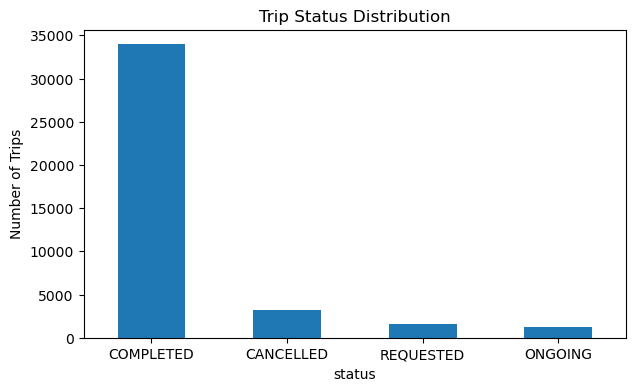

In [13]:
status_counts.plot(
    kind="bar",
    figsize=(7,4),
    title="Trip Status Distribution"
)

plt.ylabel("Number of Trips")
plt.xticks(rotation=0)

plt.show()

Approximately 84.9% of trips were successfully completed,
while cancellations remained relatively low,
indicating strong operational fulfillment efficiency.

## 7. REVENUE BY CITY
Evaluate which cities contribute most
to total platform revenue.

In [14]:
city_revenue = (
    df.groupby("city")["fare"]
    .sum()
    .sort_values(ascending=False)
)

city_revenue

city
Mumbai       2.492157e+06
Delhi        2.131173e+06
Bangalore    1.791860e+06
Hyderabad    1.204422e+06
Chennai      1.002010e+06
Pune         7.982820e+05
Kolkata      4.898201e+05
Name: fare, dtype: float64

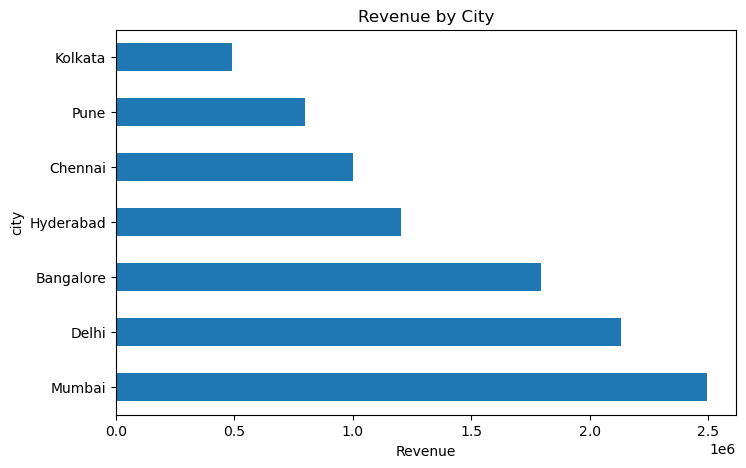

In [15]:
city_revenue.plot(
    kind="barh",
    figsize=(8,5),
    title="Revenue by City"
)

plt.xlabel("Revenue")

plt.show()

Mumbai generated the highest total revenue,
suggesting stronger platform demand and ride activity
compared to other cities.

## 8. PEAK DEMAND ANALYSIS

In [16]:
hourly_trips = (
    df.groupby("hour")
    .size()
)

hourly_trips

hour
0     1108
1     1112
2     1198
3     1170
4     1119
5     1129
6     1135
7      817
8      794
9      748
10     809
11     812
12    2737
13    2642
14    2541
15    1359
16    1411
17    1465
18    1456
19    3563
20    3521
21    3727
22    3627
dtype: int64

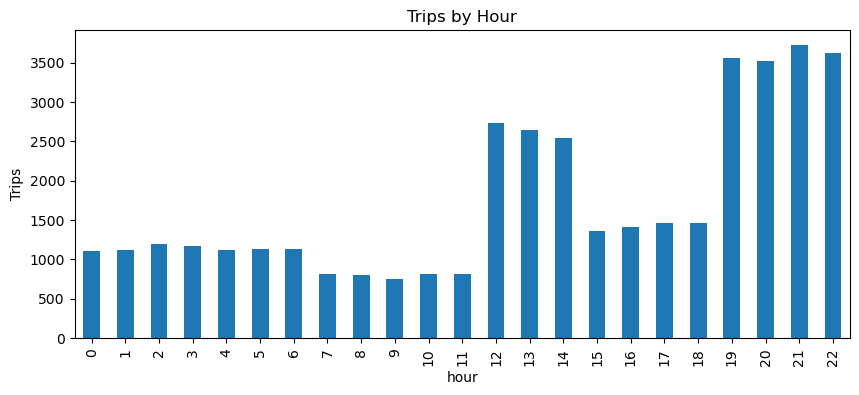

In [17]:
hourly_trips.plot(
    kind="bar",
    figsize=(10,4),
    title="Trips by Hour"
)

plt.ylabel("Trips")

plt.show()

Peak ride demand occurs during the 7–10 PM window,
with highest activity at 9 PM, suggesting evening commuting
and return-home travel drive platform demand.

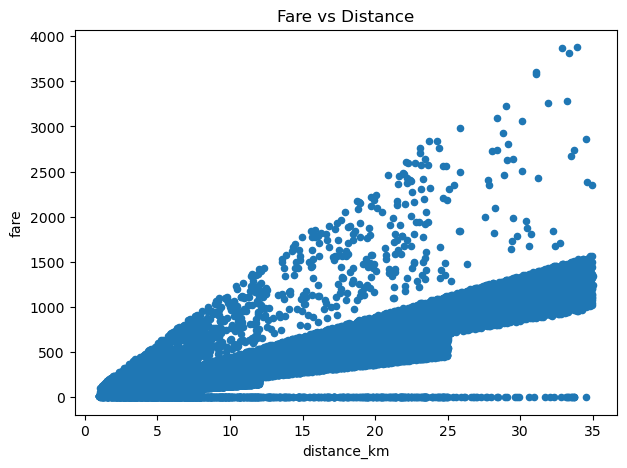

In [18]:
df.plot.scatter(
    x="distance_km",
    y="fare",
    figsize=(7,5),
    title="Fare vs Distance"
)

plt.show()

Fare generally increases with distance,
showing a positive relationship between trip length
and ride pricing.

## 9. FINAL BUSINESS RECOMMENDATIONS
# Final Recommendations

- Increase driver allocation during 7–10 PM peak hours
  to improve fulfillment efficiency.

- Focus on increasing ride volume in high-performing cities
  such as Mumbai and Delhi.

- Continue monitoring cancellation rates,
  though current operational performance appears stable.

- High fare-per-km trips are primarily caused by
  short-distance rides with fixed base charges,
  rather than likely pricing anomalies.